<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase2/New_IDW_Add_PM25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

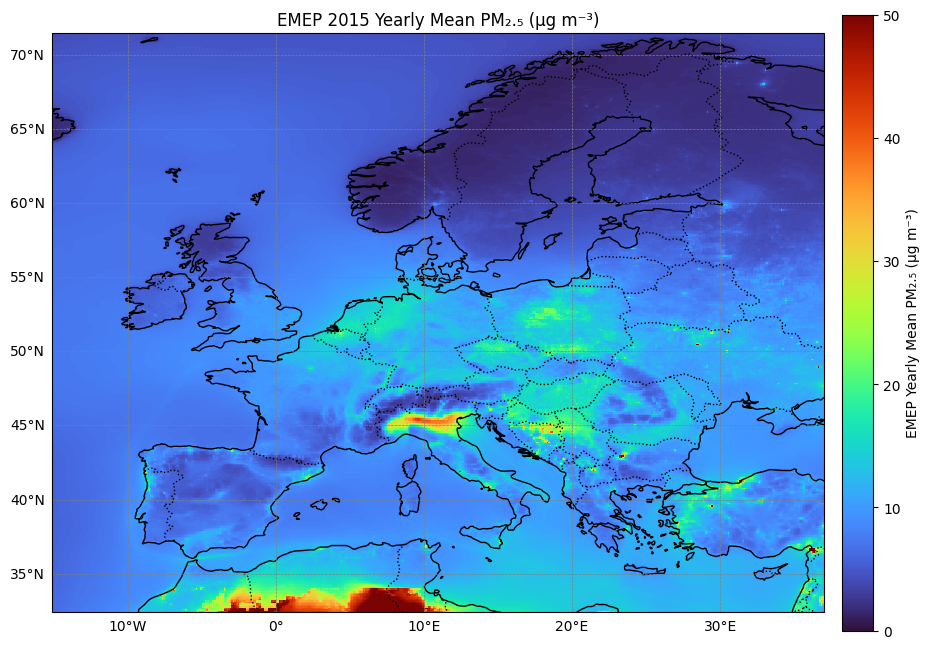

In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the EMEP PM2.5 NetCDF File ===
emep_netcdf_path = "EMEP_yearly_2015.nc"
ds = xr.open_dataset(emep_netcdf_path)

# Extract PM2.5 values (μg m⁻³)
pm25 = ds["SURF_ug_PM25_rh50"].squeeze().values

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Create 2D meshgrid
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization (adjusted for PM2.5) ===
norm = mcolors.Normalize(0, 50)

# Create map
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot PM2.5 field
mesh = ax.pcolormesh(
    Lon,
    Lat,
    pm25,
    cmap='turbo',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("EMEP Yearly Mean PM₂.₅ (μg m⁻³)")

# Coastlines & borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Title
ax.set_title("EMEP 2015 Yearly Mean PM₂.₅ (μg m⁻³)")

plt.show()

ds.close()

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np

# ======================================================
# 1 Load EMEP NetCDF
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")

lat_array = ds["lat"].values
lon_array = ds["lon"].values
pm_model = ds["SURF_ug_PM25_rh50"].isel(time=0).values  # shape (lat, lon)

# ======================================================
# 2 Load station CSV
# ======================================================
stations = pd.read_csv("yearly_PM25_2015.csv")

# Keep only stations inside EMEP domain
stations = stations[
    (stations["Latitude"] >= lat_array.min()) &
    (stations["Latitude"] <= lat_array.max()) &
    (stations["Longitude"] >= lon_array.min()) &
    (stations["Longitude"] <= lon_array.max())
].copy()

# ======================================================
# 3 Assign nearest grid cell
# ======================================================
lat_idx = np.abs(lat_array[:, None] - stations["Latitude"].values).argmin(axis=0)
lon_idx = np.abs(lon_array[:, None] - stations["Longitude"].values).argmin(axis=0)

stations["lat_idx"] = lat_idx
stations["lon_idx"] = lon_idx

stations["nearest_grid_lat"] = lat_array[lat_idx]
stations["nearest_grid_lon"] = lon_array[lon_idx]

stations["grid_cell_index"] = list(zip(
    stations["nearest_grid_lon"],
    stations["nearest_grid_lat"]
))

# ======================================================
# 4 Average stations per grid cell
# ======================================================
grid_agg = (
    stations.groupby(
        ["lon_idx", "lat_idx",
         "nearest_grid_lon", "nearest_grid_lat", "grid_cell_index"]
    )
    .agg(
        SURF_ug_PM25_rh50=("Average", "mean"),
        n_stations=("Average", "count")
    )
    .reset_index()
)

# ======================================================
# 5 Extract EMEP model value
# ======================================================
grid_agg["nearest_SURF_ug_PM25_rh50"] = [
    pm_model[i, j]
    for i, j in zip(grid_agg["lat_idx"], grid_agg["lon_idx"])
]

# ======================================================
# 6 Final structure
# ======================================================
final_df = grid_agg[[
    "nearest_grid_lon",
    "nearest_grid_lat",
    "grid_cell_index",
    "SURF_ug_PM25_rh50",
    "nearest_SURF_ug_PM25_rh50",
    "n_stations"
]]

# ======================================================
# 7 Save file
# ======================================================
final_df.to_csv("basePM25_gridcell_average.csv", index=False)

print("Done. File saved as 'basePM25_gridcell_average.csv'")
print("Total grid cells with observations:", len(final_df))


Done. File saved as 'basePM25_gridcell_average.csv'
Total grid cells with observations: 599


In [ ]:
import numpy as np
import pandas as pd
import netCDF4 as nc
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import itertools
from sklearn.neighbors import BallTree

# ======================================================
# LOAD DATA
# ======================================================
df = pd.read_csv("basePM25_gridcell_average.csv")

# === ADDITIVE BIAS ===
df["bias"] = df["SURF_ug_PM25_rh50"] - df["nearest_SURF_ug_PM25_rh50"]

dataset = nc.Dataset("EMEP_yearly_2015.nc", "r")
lon = dataset.variables["lon"][:]
lat = dataset.variables["lat"][:]
model = dataset.variables["SURF_ug_PM25_rh50"][0, :, :]

# ======================================================
# PREPARE DATA
# ======================================================
cell_points = np.column_stack([
    np.radians(df["nearest_grid_lat"].values),
    np.radians(df["nearest_grid_lon"].values)
])

bias_values = df["bias"].values
obs_values = df["SURF_ug_PM25_rh50"].values
model_values = df["nearest_SURF_ug_PM25_rh50"].values

# === GRID INDEX MAPPING (CRITICAL — SAME AS MULTIPLICATIVE) ===
cell_indices = [
    (
        np.argmin(np.abs(lat - df["nearest_grid_lat"].iloc[i])),
        np.argmin(np.abs(lon - df["nearest_grid_lon"].iloc[i]))
    )
    for i in range(len(df))
]

# ======================================================
# PARAMETERS
# ======================================================
p_values = np.arange(0.5, 3.1, 0.1)
k_values = np.arange(2, 41)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
best_rmse = float("inf")
best_params = None

# ======================================================
# GRID SEARCH (OPTIMIZED ON CONCENTRATIONS)
# ======================================================
with tqdm(total=len(p_values) * len(k_values), desc="Grid Search (Additive)") as pbar:

    for p, k in itertools.product(p_values, k_values):

        all_obs = []
        all_pred = []

        for train_idx, val_idx in kf.split(cell_points):

            train_points = cell_points[train_idx]
            train_bias = bias_values[train_idx]

            val_points = cell_points[val_idx]
            val_obs = obs_values[val_idx]
            val_model = model_values[val_idx]

            tree = BallTree(train_points, metric="haversine")
            dists, idxs = tree.query(val_points, k=k)

            dists = np.maximum(dists, 1e-12)

            weights = 1 / (dists ** p)
            weights /= weights.sum(axis=1, keepdims=True)

            interpolated_bias = np.sum(weights * train_bias[idxs], axis=1)

            # === ADDITIVE CORRECTION ===
            val_pred = val_model + interpolated_bias

            all_obs.extend(val_obs)
            all_pred.extend(val_pred)

        all_obs = np.array(all_obs)
        all_pred = np.array(all_pred)

        rmse = np.sqrt(mean_squared_error(all_obs, all_pred))
        mae = mean_absolute_error(all_obs, all_pred)
        mbe = np.mean(all_pred - all_obs)
        r2 = r2_score(all_obs, all_pred)

        results.append((p, k, rmse, mae, mbe, r2))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = (p, k)

        pbar.update(1)

# ======================================================
# SAVE RESULTS
# ======================================================
results_df = pd.DataFrame(
    results,
    columns=["p", "k", "RMSE", "MAE", "MBE", "R2"]
)

results_df.to_csv("BaseCase_PM25_Y_IDW_ADD_metrics.csv", index=False)

print(f"\nBEST PARAMETERS: p={best_params[0]}, k={best_params[1]} | RMSE={best_rmse:.4f}")

# ======================================================
# FINAL MODEL (FULL GRID INTERPOLATION)
# ======================================================
print("\nApplying final additive model...")

lon_mesh, lat_mesh = np.meshgrid(lon, lat)
grid_points = np.column_stack([
    np.radians(lat_mesh.ravel()),
    np.radians(lon_mesh.ravel())
])

tree = BallTree(cell_points, metric="haversine")
dists, idxs = tree.query(grid_points, k=best_params[1])

dists = np.maximum(dists, 1e-12)

weights = 1 / (dists ** best_params[0])
weights /= weights.sum(axis=1, keepdims=True)

final_bias = np.sum(weights * bias_values[idxs], axis=1)
final_bias = final_bias.reshape(model.shape)

# ======================================================
# SAVE NETCDF (INTERPOLATED BIAS)
# ======================================================
out_nc = nc.Dataset("BaseCase_PM25_Y_IDW_ADD.nc", "w", format="NETCDF4")

out_nc.createDimension("lat", len(lat))
out_nc.createDimension("lon", len(lon))

lat_var = out_nc.createVariable("lat", "f4", ("lat",))
lon_var = out_nc.createVariable("lon", "f4", ("lon",))
bias_var = out_nc.createVariable("Interpolated_Bias", "f4", ("lat", "lon"))

lat_var[:] = lat
lon_var[:] = lon
bias_var[:, :] = final_bias

out_nc.close()

print("Saved: BaseCase_PM25_Y_IDW_ADD.nc")

Grid Search (Additive): 100%|██████████| 1014/1014 [00:23<00:00, 42.68it/s]



BEST PARAMETERS: p=0.8999999999999999, k=7 | RMSE=3.6295

Applying final additive model...
Saved: BaseCase_PM25_Y_IDW_ADD.nc



=== DATA RANGES ===
RMSE: min=3.6295, max=4.1913
MAE: min=2.2599, max=2.6875
R2: min=0.6087, max=0.7066
MBE: min=-0.2478, max=-0.0516


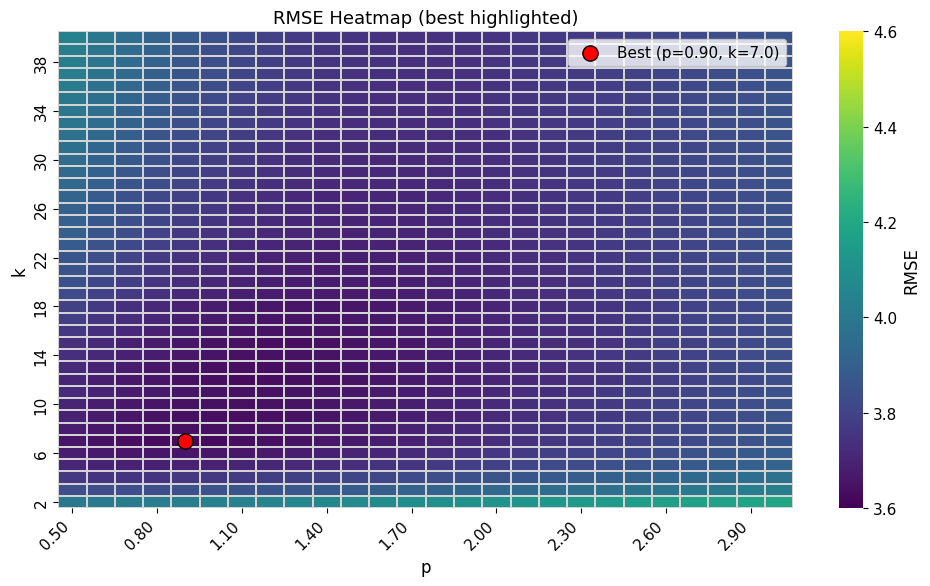

RMSE best → p=0.90, k=7.0, value=3.6295


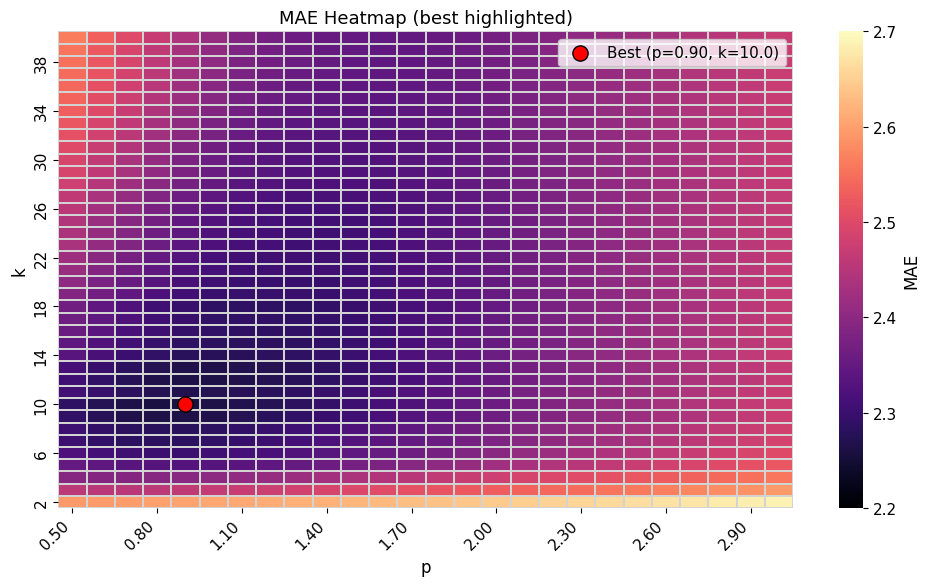

MAE best → p=0.90, k=10.0, value=2.2599


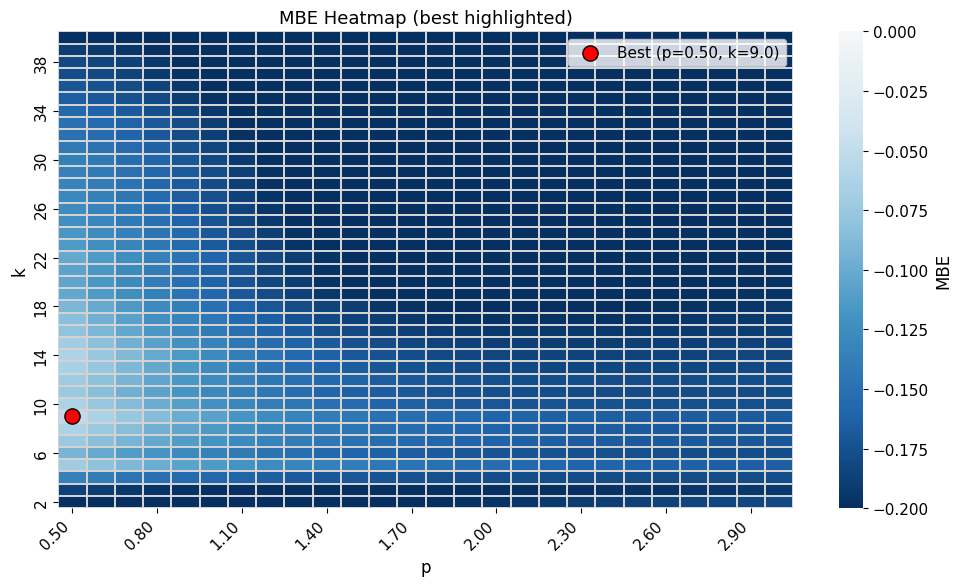

MBE best → p=0.50, k=9.0, value=-0.0516


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# GLOBAL STYLE (clean)
# ======================================================
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12
})

# ======================================================
# 1. LOAD RESULTS
# ======================================================
df = pd.read_csv("BaseCase_PM25_Y_IDW_ADD_metrics.csv")

df["p"] = df["p"].astype(float).round(2)   # FIX float noise
df["k"] = df["k"].astype(int)

# ======================================================
# 2. PRINT REAL DATA RANGES
# ======================================================
print("\n=== DATA RANGES ===")
for col in ["RMSE", "MAE", "R2", "MBE"]:
    print(f"{col}: min={df[col].min():.4f}, max={df[col].max():.4f}")

# ======================================================
# 3. GET BEST (p, k) PER METRIC
# ======================================================
def get_best_params(metric):

    if metric in ["RMSE", "MAE"]:
        row = df.loc[df[metric].idxmin()]

    elif metric == "R2":
        row = df.loc[df[metric].idxmax()]

    elif metric == "MBE":
        row = df.iloc[(df["MBE"].abs()).idxmin()]

    else:
        raise ValueError("Unknown metric")

    return row["p"], row["k"], row[metric]

# ======================================================
# 4. HEATMAP FUNCTION (FIXED AXES)
# ======================================================
def plot_heatmap(metric, cmap="viridis", center=None, vmin=None, vmax=None):

    pivot = df.pivot(index="k", columns="p", values=metric)
    pivot = pivot.sort_index().sort_index(axis=1)

    # Fix floating precision in axis
    pivot.columns = pivot.columns.round(2)

    best_p, best_k, best_val = get_best_params(metric)

    plt.figure(figsize=(10, 6))

    ax = sns.heatmap(
        pivot,
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.1,
        linecolor="lightgray",
        cbar_kws={"label": metric}
    )

    plt.title(f"{metric} Heatmap (best highlighted)")
    plt.xlabel("p")
    plt.ylabel("k")

    # ==================================================
    # CLEAN AXES (KEY FIX)
    # ==================================================
    step_x = 3   # reduce p ticks
    step_y = 4   # reduce k ticks

    ax.set_xticks(np.arange(0, len(pivot.columns), step_x) + 0.5)
    ax.set_xticklabels(
        [f"{p:.2f}" for p in pivot.columns[::step_x]],
        rotation=45,
        ha="right"
    )

    ax.set_yticks(np.arange(0, len(pivot.index), step_y) + 0.5)
    ax.set_yticklabels(pivot.index[::step_y])

    # ==================================================
    # BEST POINT
    # ==================================================
    x_idx = list(pivot.columns).index(round(best_p, 2))
    y_idx = list(pivot.index).index(best_k)

    plt.scatter(
        x_idx + 0.5,
        y_idx + 0.5,
        color="red",
        s=120,
        edgecolors="black",
        linewidth=1,
        label=f"Best (p={best_p:.2f}, k={best_k})"
    )

    # Optional: invert y-axis (more intuitive)
    plt.gca().invert_yaxis()

    plt.legend()
    plt.tight_layout()

    # Save figure
    plt.savefig(f"{metric}_heatmap.png", dpi=300, bbox_inches="tight")

    plt.show()

    print(f"{metric} best → p={best_p:.2f}, k={best_k}, value={best_val:.4f}")

# ======================================================
# 5. MANUAL LIMITS
# ======================================================
limits = {
    "RMSE": (3.6, 4.6),
    "MAE":  (2.2, 2.7),
    "R2":   (0, 1),
    "MBE":  (-0.2, 0)
}

# ======================================================
# 6. PLOTS
# ======================================================
plot_heatmap("RMSE", cmap="viridis",
             vmin=limits["RMSE"][0], vmax=limits["RMSE"][1])

plot_heatmap("MAE", cmap="magma",
             vmin=limits["MAE"][0], vmax=limits["MAE"][1])

plot_heatmap("MBE", cmap="RdBu_r", center=0,
             vmin=limits["MBE"][0], vmax=limits["MBE"][1])

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


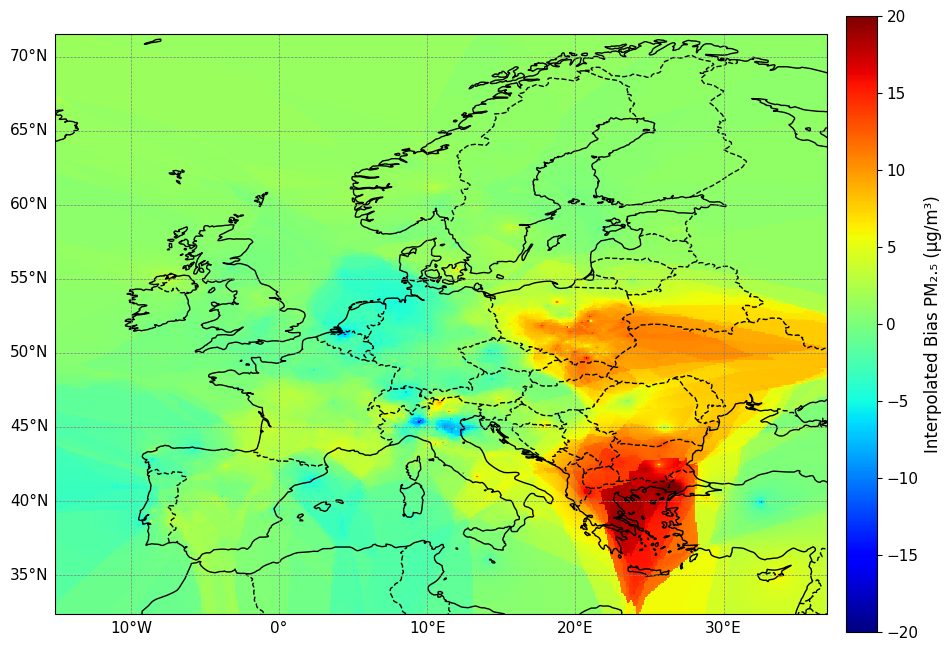

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === Load the Interpolated Bias NetCDF File ===
bias_netcdf_path = "BaseCase_PM25_Y_IDW_ADD.nc"  # File already saved
ds_bias = xr.open_dataset(bias_netcdf_path)

# Extract interpolated bias (residuals)
interpolated_bias = ds_bias["Interpolated_Bias"].squeeze().values

# Extract coordinates
lon = ds_bias["lon"].values
lat = ds_bias["lat"].values

# === Define Plot Limits (Adjust if needed) ===
cbar_min = -20  # Minimum bias value for color scale
cbar_max = 20  # Maximum bias value for color scale

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the interpolated bias
im = ax.pcolormesh(lon, lat, interpolated_bias, transform=ccrs.PlateCarree(), cmap="jet", vmin=cbar_min, vmax=cbar_max, shading='auto')

# Add colorbar
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("Interpolated Bias PM₂.₅ (µg/m³)")

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_bias.close()

In [ ]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
original_nc_path = "EMEP_yearly_2015.nc"
bias_nc_path = "BaseCase_PM25_Y_IDW_ADD.nc"
corrected_nc_path = "BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc"

# === Load the Original Modeled PM₂.₅ NetCDF ===
with nc.Dataset(original_nc_path, "r") as original_nc, nc.Dataset(bias_nc_path, "r") as bias_nc:

    # Load model coordinates and data
    lon = original_nc.variables["lon"][:]
    lat = original_nc.variables["lat"][:]
    time = original_nc.variables["time"][:]
    pm25_original = original_nc.variables["SURF_ug_PM25_rh50"][:]

    # Load the interpolated bias
    interpolated_bias = bias_nc.variables["Interpolated_Bias"][:]

    # === Compute the Unbiased PM₂.₅ ===
    pm25_corrected = pm25_original + interpolated_bias  # Apply the bias correction

    # === Save the Corrected PM₂.₅ to a New NetCDF File ===
    with nc.Dataset(corrected_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_rh50_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original PM₂.₅ variable
        pm25_var.setncatts(original_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_corrected  # Store corrected PM₂.₅

print(" Bias correction completed successfully!")
print(" Corrected PM₂.₅ NetCDF file saved as:", corrected_nc_path)

 Bias correction completed successfully!
 Corrected PM₂.₅ NetCDF file saved as: BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc


In [ ]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc"  # Your original file
output_file = "BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2015.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_rh50_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versio

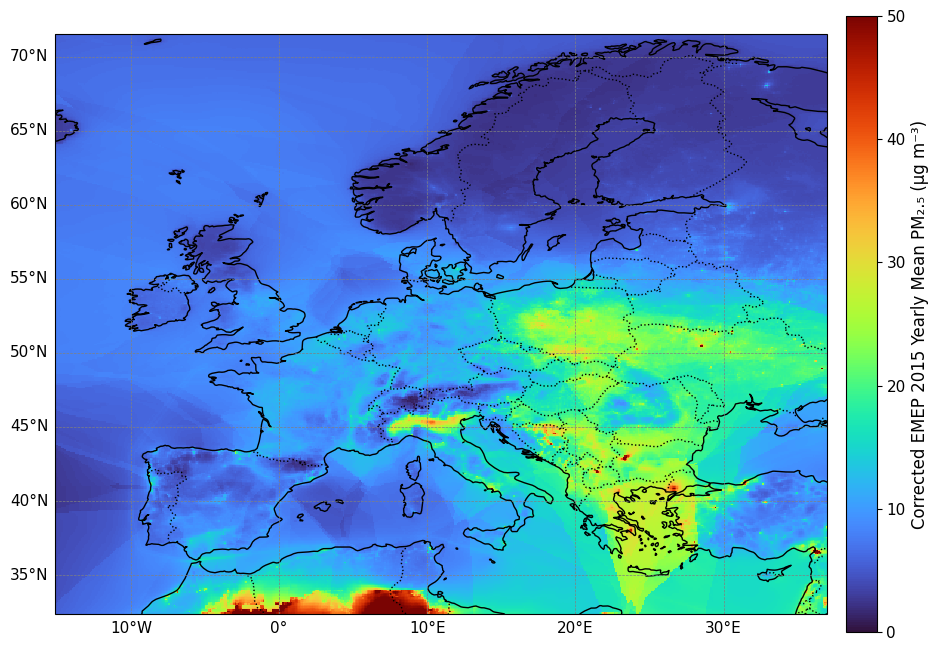

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='turbo', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2015 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()


# EMEP 2022

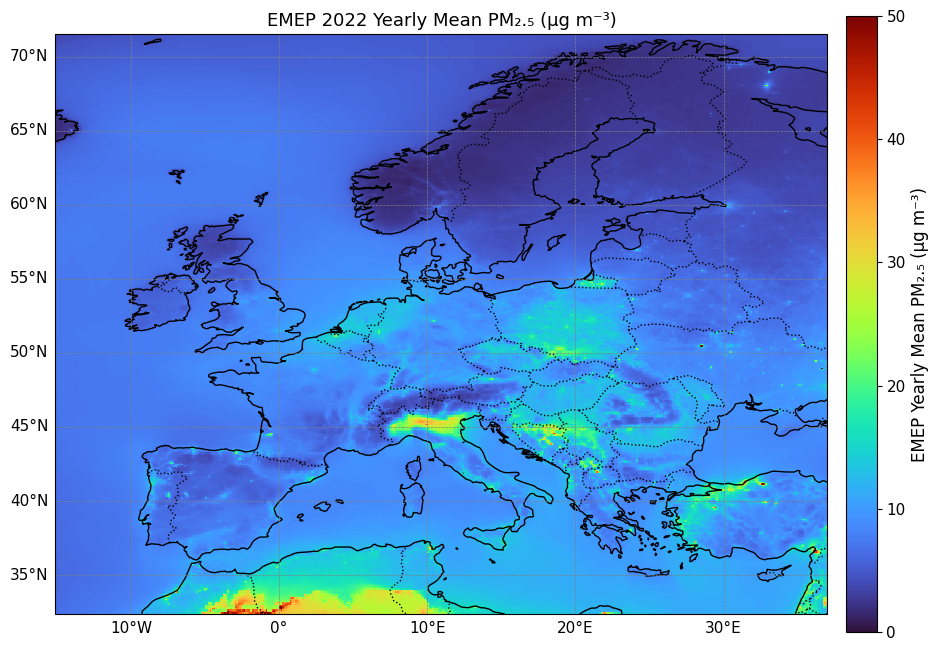

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the EMEP PM2.5 NetCDF File ===
emep_netcdf_path = "EMEP_yearly_2022.nc"
ds = xr.open_dataset(emep_netcdf_path)

# Extract PM2.5 values (μg m⁻³)
pm25 = ds["SURF_ug_PM25_rh50"].squeeze().values

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Create 2D meshgrid
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization (adjusted for PM2.5) ===
norm = mcolors.Normalize(0, 50)

# Create map
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot PM2.5 field
mesh = ax.pcolormesh(
    Lon,
    Lat,
    pm25,
    cmap='turbo',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("EMEP Yearly Mean PM₂.₅ (μg m⁻³)")

# Coastlines & borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Title
ax.set_title("EMEP 2022 Yearly Mean PM₂.₅ (μg m⁻³)")

plt.show()

ds.close()

In [ ]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
perturbed_scenario_nc_path = "EMEP_yearly_2022.nc"  # Perturbed scenario NetCDF
interpolated_residual_nc_path = "BaseCase_PM25_Y_IDW_ADD.nc"  # Interpolated residuals NetCDF
base_raw_nc_path = "EMEP_yearly_2015.nc"  # Raw modeled base NetCDF
corrected_scenario_nc_path = "Scenario_Corrected_PM25_Y_IDW_ADD.nc"  # Output corrected scenario NetCDF

# === Load NetCDF Data ===
with nc.Dataset(perturbed_scenario_nc_path, "r") as pert_nc, \
     nc.Dataset(interpolated_residual_nc_path, "r") as res_nc, \
     nc.Dataset(base_raw_nc_path, "r") as base_nc:

    # Load variables
    lon = pert_nc.variables["lon"][:]
    lat = pert_nc.variables["lat"][:]
    time = pert_nc.variables["time"][:]
    scenario_perturb = pert_nc.variables["SURF_ug_PM25_rh50"][:]
    interpolated_residual = res_nc.variables["Interpolated_Bias"][:]
    base_raw = base_nc.variables["SURF_ug_PM25_rh50"][:]  # This is your BC

    # === Compute the Unbiased Scenario ===
    threshold = 1e-4
    ratio = np.where(base_raw > threshold, interpolated_residual / base_raw, 0.0)
    scenario_corrected = scenario_perturb * (1 + ratio)

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        scenario_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original variable
        scenario_var.setncatts(pert_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        scenario_var[:] = scenario_corrected

print("Scenario Bias Correction Completed Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF file saved as:", corrected_scenario_nc_path)


Scenario Bias Correction Completed Successfully!
Corrected PM₂.₅ Scenario NetCDF file saved as: Scenario_Corrected_PM25_Y_IDW_ADD.nc


In [ ]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected_PM25_Y_IDW_ADD.nc"  # Your original file
output_file = "Scen_2022_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2022.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")



 Correction completed! Renamed and fixed NetCDF saved as: Scen_2022_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versio

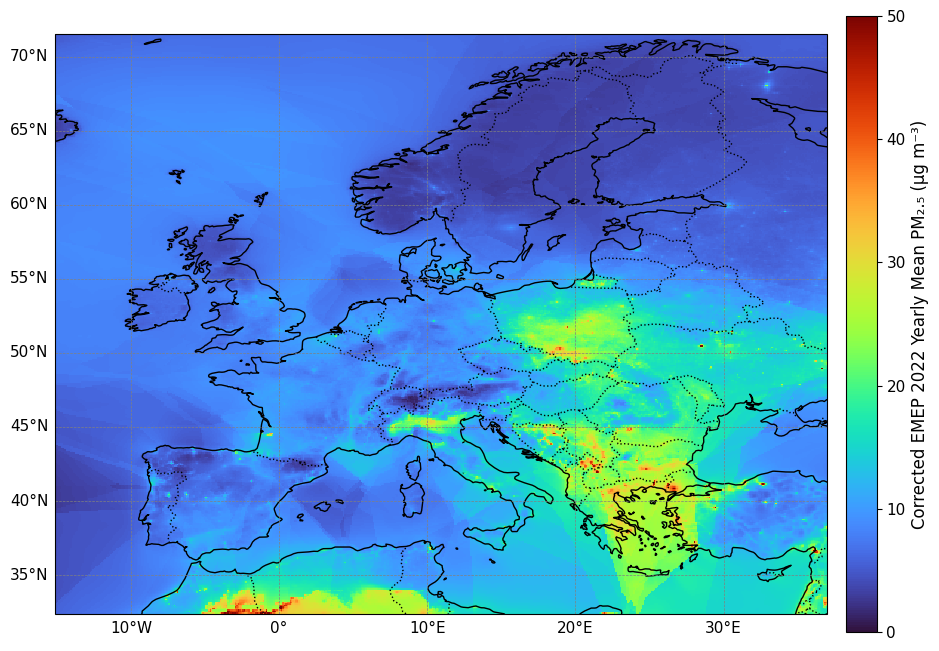

In [ ]:

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2022_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='turbo', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2022 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

# EMEP 2023

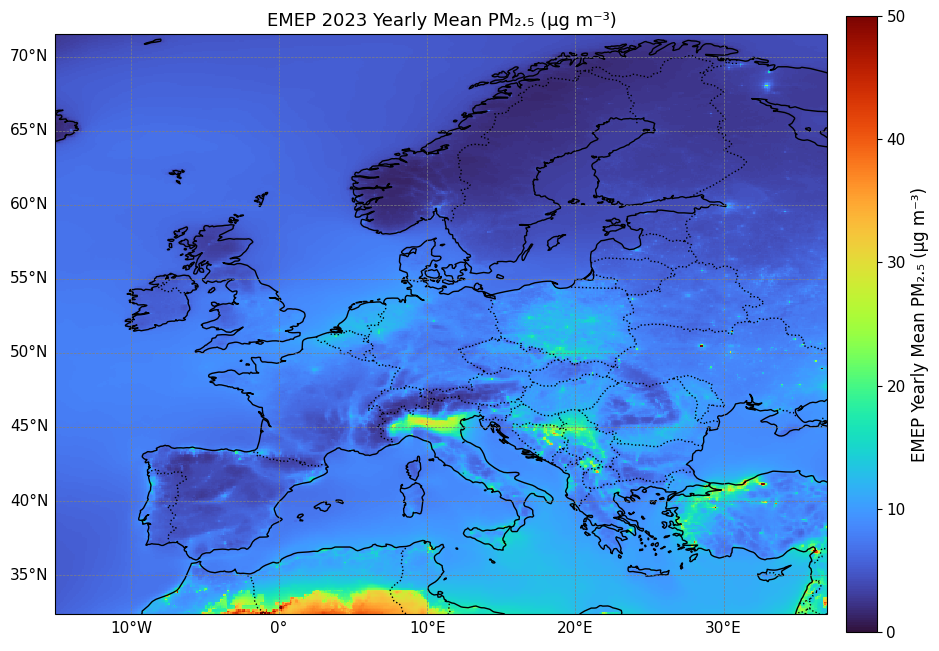

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the EMEP PM2.5 NetCDF File ===
emep_netcdf_path = "EMEP_yearly_2023.nc"
ds = xr.open_dataset(emep_netcdf_path)

# Extract PM2.5 values (μg m⁻³)
pm25 = ds["SURF_ug_PM25_rh50"].squeeze().values

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Create 2D meshgrid
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization (adjusted for PM2.5) ===
norm = mcolors.Normalize(0, 50)

# Create map
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot PM2.5 field
mesh = ax.pcolormesh(
    Lon,
    Lat,
    pm25,
    cmap='turbo',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("EMEP Yearly Mean PM₂.₅ (μg m⁻³)")

# Coastlines & borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Title
ax.set_title("EMEP 2023 Yearly Mean PM₂.₅ (μg m⁻³)")

plt.show()

ds.close()

In [ ]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
perturbed_scenario_nc_path = "EMEP_yearly_2023.nc"  # Perturbed scenario NetCDF
interpolated_residual_nc_path = "BaseCase_PM25_Y_IDW_ADD.nc"  # Interpolated residuals NetCDF
base_raw_nc_path = "EMEP_yearly_2015.nc"  # Raw modeled base NetCDF
corrected_scenario_nc_path = "Scenario_Corrected3_PM25_Y_IDW_ADD.nc"  # Output corrected scenario NetCDF

# === Load NetCDF Data ===
with nc.Dataset(perturbed_scenario_nc_path, "r") as pert_nc, \
     nc.Dataset(interpolated_residual_nc_path, "r") as res_nc, \
     nc.Dataset(base_raw_nc_path, "r") as base_nc:

    # Load variables
    lon = pert_nc.variables["lon"][:]
    lat = pert_nc.variables["lat"][:]
    time = pert_nc.variables["time"][:]
    scenario_perturb = pert_nc.variables["SURF_ug_PM25_rh50"][:]
    interpolated_residual = res_nc.variables["Interpolated_Bias"][:]
    base_raw = base_nc.variables["SURF_ug_PM25_rh50"][:]  # This is your BC

    # === Compute the Unbiased Scenario ===
    threshold = 1e-4
    ratio = np.where(base_raw > threshold, interpolated_residual / base_raw, 0.0)
    scenario_corrected = scenario_perturb * (1 + ratio)

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        scenario_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original variable
        scenario_var.setncatts(pert_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        scenario_var[:] = scenario_corrected

print("Scenario Bias Correction Completed Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF file saved as:", corrected_scenario_nc_path)


Scenario Bias Correction Completed Successfully!
Corrected PM₂.₅ Scenario NetCDF file saved as: Scenario_Corrected3_PM25_Y_IDW_ADD.nc


In [ ]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected3_PM25_Y_IDW_ADD.nc"  # Your original file
output_file = "Scen_2023_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2023.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")



 Correction completed! Renamed and fixed NetCDF saved as: Scen_2023_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versio

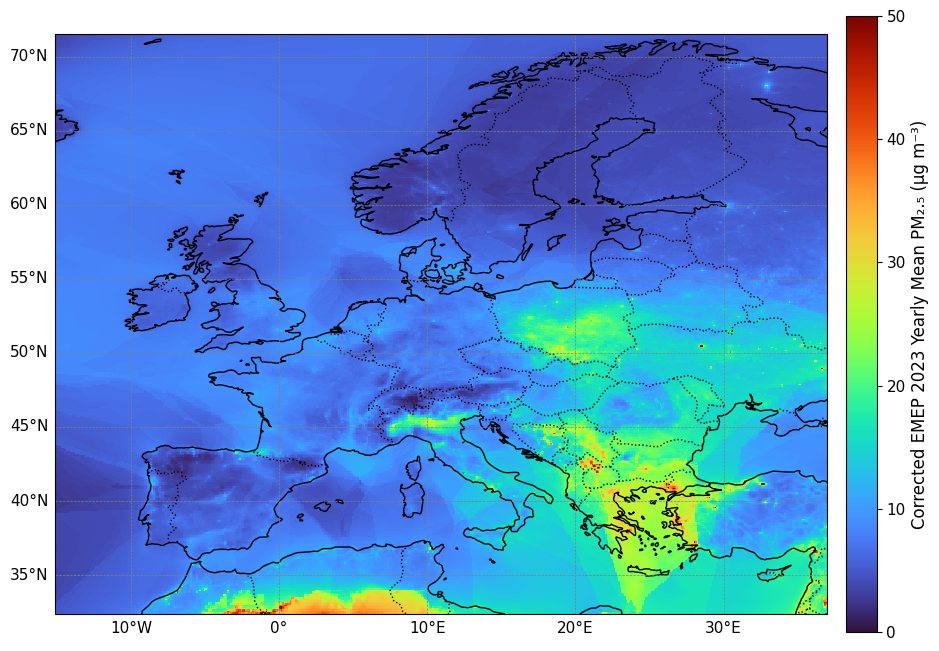

In [ ]:

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2023_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='turbo', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2023 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

# EMEP 2024

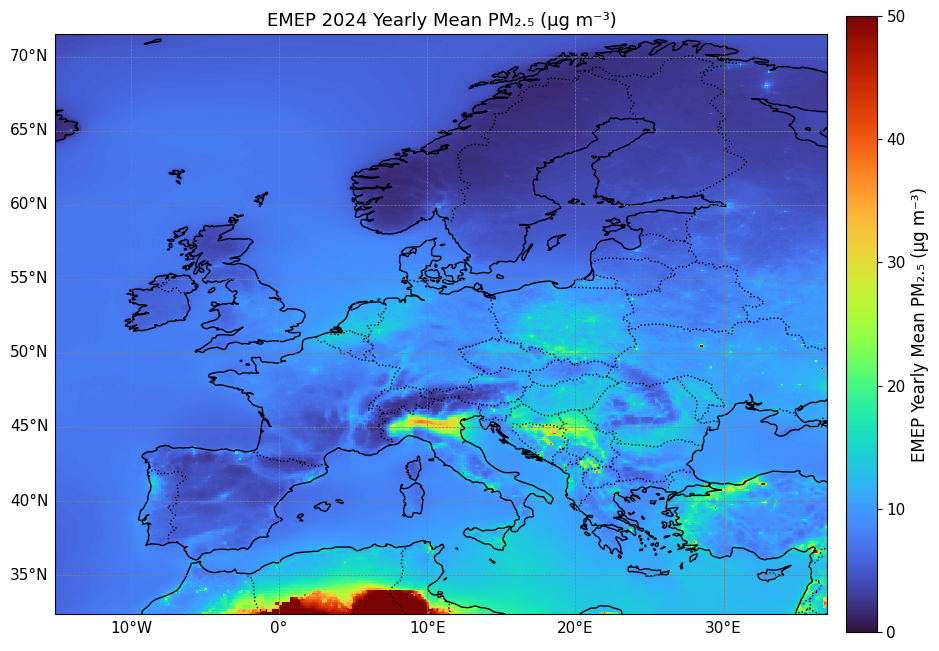

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the EMEP PM2.5 NetCDF File ===
emep_netcdf_path = "EMEP_yearly_2024.nc"
ds = xr.open_dataset(emep_netcdf_path)

# Extract PM2.5 values (μg m⁻³)
pm25 = ds["SURF_ug_PM25_rh50"].squeeze().values

# Extract coordinates
lon = ds["lon"].values
lat = ds["lat"].values

# Create 2D meshgrid
Lon, Lat = np.meshgrid(lon, lat)

# === Define Color Normalization (adjusted for PM2.5) ===
norm = mcolors.Normalize(0, 50)

# Create map
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Plot PM2.5 field
mesh = ax.pcolormesh(
    Lon,
    Lat,
    pm25,
    cmap='turbo',
    shading='auto',
    transform=ccrs.PlateCarree(),
    norm=norm
)

# Colorbar
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("EMEP Yearly Mean PM₂.₅ (μg m⁻³)")

# Coastlines & borders
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Gridlines
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False
gl.right_labels = False

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Title
ax.set_title("EMEP 2024 Yearly Mean PM₂.₅ (μg m⁻³)")

plt.show()

ds.close()

In [ ]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
perturbed_scenario_nc_path = "EMEP_yearly_2024.nc"  # Perturbed scenario NetCDF
interpolated_residual_nc_path = "BaseCase_PM25_Y_IDW_ADD.nc"  # Interpolated residuals NetCDF
base_raw_nc_path = "EMEP_yearly_2015.nc"  # Raw modeled base NetCDF
corrected_scenario_nc_path = "Scenario_Corrected4_PM25_Y_IDW_ADD.nc"  # Output corrected scenario NetCDF

# === Load NetCDF Data ===
with nc.Dataset(perturbed_scenario_nc_path, "r") as pert_nc, \
     nc.Dataset(interpolated_residual_nc_path, "r") as res_nc, \
     nc.Dataset(base_raw_nc_path, "r") as base_nc:

    # Load variables
    lon = pert_nc.variables["lon"][:]
    lat = pert_nc.variables["lat"][:]
    time = pert_nc.variables["time"][:]
    scenario_perturb = pert_nc.variables["SURF_ug_PM25_rh50"][:]
    interpolated_residual = res_nc.variables["Interpolated_Bias"][:]
    base_raw = base_nc.variables["SURF_ug_PM25_rh50"][:]  # This is your BC

    # === Compute the Unbiased Scenario ===
    threshold = 1e-4
    ratio = np.where(base_raw > threshold, interpolated_residual / base_raw, 0.0)
    scenario_corrected = scenario_perturb * (1 + ratio)

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        scenario_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original variable
        scenario_var.setncatts(pert_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        scenario_var[:] = scenario_corrected

print("Scenario Bias Correction Completed Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF file saved as:", corrected_scenario_nc_path)


Scenario Bias Correction Completed Successfully!
Corrected PM₂.₅ Scenario NetCDF file saved as: Scenario_Corrected4_PM25_Y_IDW_ADD.nc


In [ ]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected4_PM25_Y_IDW_ADD.nc"  # Your original file
output_file = "Scen_2024_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2024.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")



 Correction completed! Renamed and fixed NetCDF saved as: Scen_2024_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versio

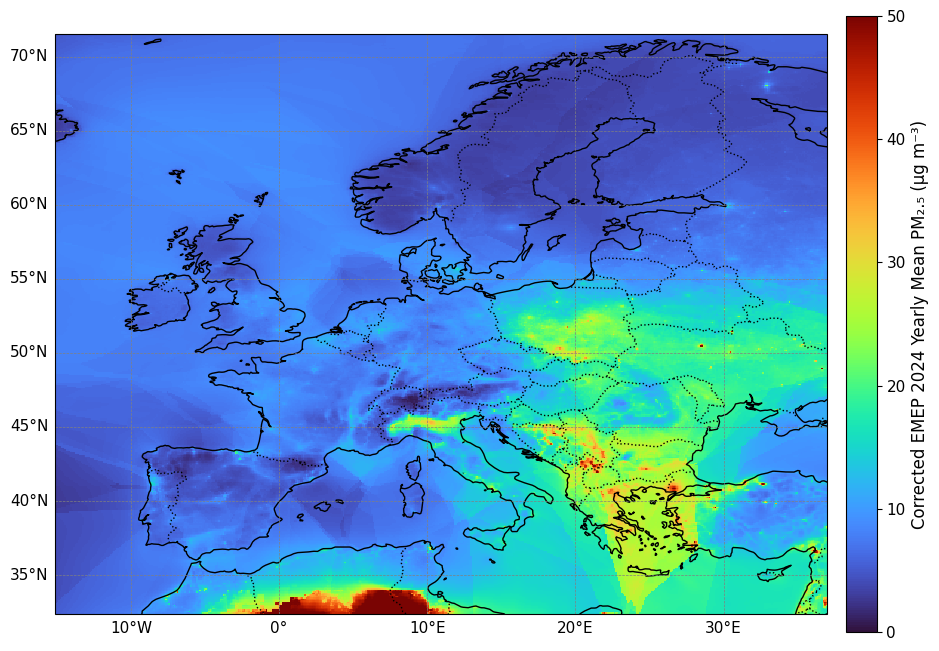

In [ ]:

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2024_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 50)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='turbo', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2024 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [ ]:
import numpy as np
import os

input_dir = "/content/PM25"
output_dir = "/content/Results_PM25"

variables_to_fix = [
    "SURF_ug_NO2",
    "SURF_ug_O3",              # corrected name
    "SURF_ug_PM25_rh50"
]

correct_dims = ("time", "lat", "lon")

os.makedirs(output_dir, exist_ok=True)

for file in os.listdir(input_dir):
    if file.endswith(".nc"):

        input_path = os.path.join(input_dir, file)
        output_path = os.path.join(output_dir, file)

        print(f"\nProcessing: {file}")

        with nc.Dataset(input_path, "r") as src:
            lon = src.variables["lon"][:]
            lat = src.variables["lat"][:]
            time = src.variables["time"][:]

            global_attrs = {attr: src.getncattr(attr) for attr in src.ncattrs()}

            with nc.Dataset(output_path, "w", format="NETCDF4") as dst:

                # === FIXED DIMENSIONS ===
                dst.createDimension("lon", len(lon))
                dst.createDimension("lat", len(lat))
                dst.createDimension("time", len(time))   # NOT unlimited

                # === COORDINATES (correct dtype) ===
                lon_var = dst.createVariable("lon", "f8", ("lon",))
                lat_var = dst.createVariable("lat", "f8", ("lat",))
                time_var = dst.createVariable("time", "f8", ("time",))

                lon_var[:] = lon
                lat_var[:] = lat
                time_var[:] = time

                # Copy coordinate attributes
                for coord in ["lon", "lat", "time"]:
                    for attr in src.variables[coord].ncattrs():
                        getattr(dst.variables[coord], "setncattr")(
                            attr, src.variables[coord].getncattr(attr)
                        )

                # === Global attributes ===
                for attr, value in global_attrs.items():
                    dst.setncattr(attr, value)

                # === Variables ===
                for var_name in variables_to_fix:

                    if var_name not in src.variables:
                        print(f"  ⚠ {var_name} not found.")
                        continue

                    var = src.variables[var_name]
                    dims = var.dimensions
                    data = var[:]
                    var_attrs = {a: var.getncattr(a) for a in var.ncattrs()}

                    # === Reshape if needed ===
                    if dims != correct_dims:

                        print(f"   Reshaping {var_name}: {dims} → {correct_dims}")

                        if dims == ("lon", "lat", "time"):
                            data = np.transpose(data, (2, 1, 0))
                        elif dims == ("lat", "lon", "time"):
                            data = np.transpose(data, (2, 0, 1))
                        else:
                            print(f"   ⚠ Unknown dimension order {dims}")
                            continue

                    # === Write variable ===
                    fill_value = var_attrs.pop("_FillValue", -9999.0)

                    var_out = dst.createVariable(
                        var_name,
                        "f4",
                        correct_dims,
                        fill_value=fill_value
                    )

                    for attr, value in var_attrs.items():
                        var_out.setncattr(attr, value)

                    var_out[:] = data

        print(f"  ✔ Saved to {output_path}")

print("\n✔ All files processed correctly.")


Processing: Scen_2023_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh50: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ✔ Saved to /content/Results_PM25/Scen_2023_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

Processing: Scen_2022_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh50: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ✔ Saved to /content/Results_PM25/Scen_2022_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

Processing: Scen_2024_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh50: ('lon', 'lat', 'time') → ('time', 'lat', 'lon')
  ✔ Saved to /content/Results_PM25/Scen_2024_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

Processing: BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc
  ⚠ SURF_ug_NO2 not found.
  ⚠ SURF_ug_O3 not found.
   Reshaping SURF_ug_PM25_rh50: ('l

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 5.34951963918155
MAE: 3.5009812719240316
Bias: -0.8946399658816315
R: 0.6566782182580991
R² (corr): 0.43122628233463167
R² (true): 0.36288490756535396

WDI
RMSE: 0.25901580218935755
MAE: 0.04636224960549007
Bias: 3.0529903415252425e-08
R: 0.9992529096874191
R² (corr): 0.9985063775187734
R² (true): 0.9985063775187724

===== COUNTRY METRICS =====
   Country   RMSE_Raw      RMSE_WDI   Bias_Raw      Bias_WDI    R2_Raw  \
9       EE   1.292165  1.045510e-07  -0.835663 -1.335144e-08  0.606633   
11      FI   0.920696  1.754761e-07  -0.920696 -1.754761e-07       NaN   
17      LT   1.321742  2.415640e-07  -1.033355  2.250671e-07  1.000000   
21      NO   1.952669  2.691285e-07  -1.029712  4.725986e-08  0.592178   
19      MT   2.723544  2.746582e-07   2.723544  2.746582e-07       NaN   
26      SI   0.800919  3.354910e-07   0.296397  2.517700e-07  0.991985   
13      GB   1.707116  3.516477e-07   0.027393 -8.982997e-09  

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


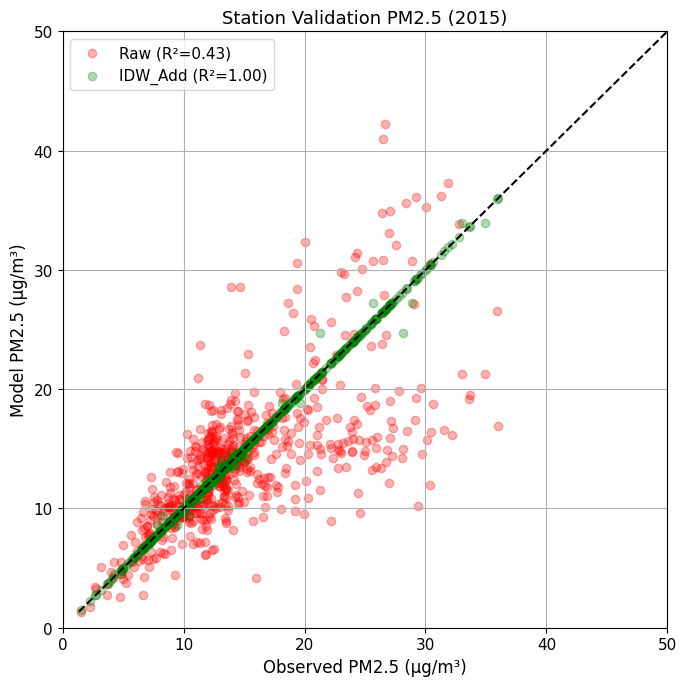

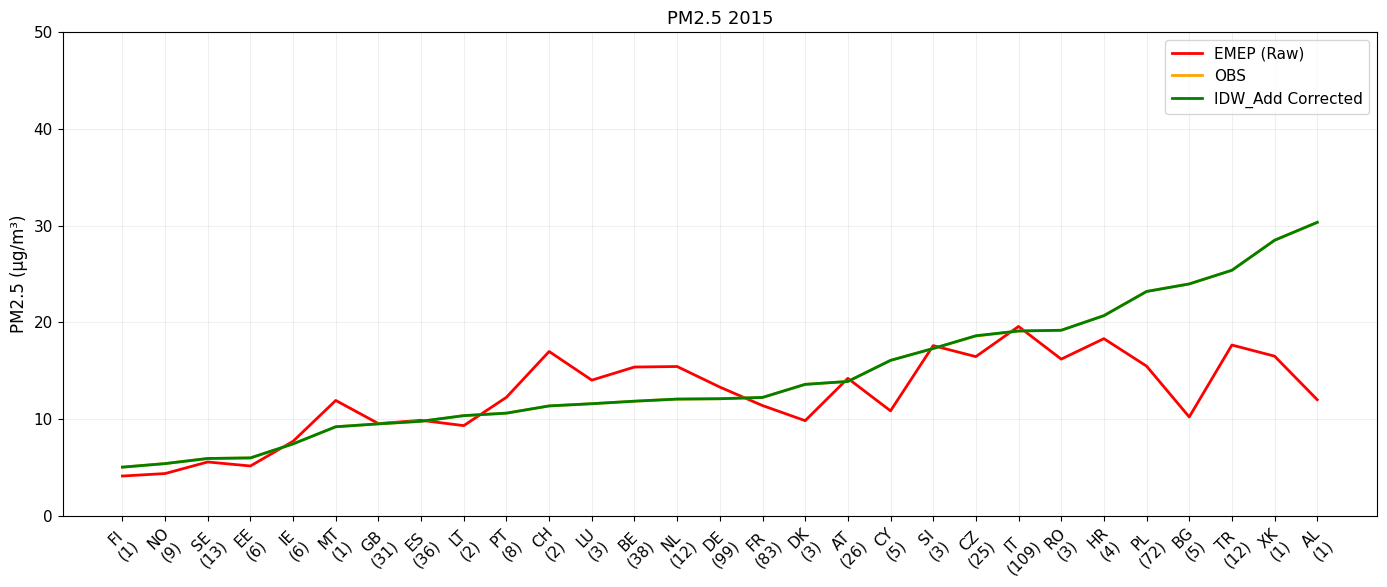

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2015.nc")
ds_wdi = xr.open_dataset("BaseCase_NKUA_PM25_CSA.Cell.Add.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2015.csv")

# fix longitude if needed
if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. NEAREST GRID CELL (SAME LOGIC)
# ======================================================
def nearest_cell_value(lon_pt, lat_pt, lon, lat, field):
    i = np.argmin(np.abs(lon - lon_pt))
    j = np.argmin(np.abs(lat - lat_pt))
    return field[j, i]

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(nearest_cell_value(lo, la, lon, lat, raw))
    wdi_vals.append(nearest_cell_value(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nWDI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Add (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM2.5 (μg/m³)")
plt.ylabel("Model PM2.5 (μg/m³)")
plt.title("Station Validation PM2.5 (2015)")
plt.legend()
plt.xlim(0,50)
plt.ylim(0,50)
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Add Corrected")
plt.ylim(0,50)
plt.xticks(x, labels, rotation=45)
plt.ylabel("PM2.5 (μg/m³)")
plt.title("PM2.5 2015")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 3.323803780061909
MAE: 2.4538563790576995
Bias: 1.4452571404908365
R: 0.802088837772308
R² (corr): 0.6433465036789318
R² (true): 0.41020473098467247

WDI
RMSE: 4.559465209394742
MAE: 2.7791427854302326
Bias: 2.4276829896895764
R: 0.8448653000357571
R² (corr): 0.7137973752045099
R² (true): -0.10983480961226588


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)



===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
20      SE  0.587142   0.673082  0.386895   0.463471  0.978012  0.969110   4
12      IE  1.114951   0.899452  0.734412   0.424605  0.670979  0.779755   4
6       DE  2.199415   1.024460  1.487608   0.590351  0.270045  0.752219  86
3       CH  3.321455   1.050137  3.113162  -1.032991  1.000000  1.000000   2
1       BE  3.492568   1.602070  3.326808   0.826596  0.853285  0.732850  30
15      NL  4.277522   1.685482  4.232454   1.335790  0.003806  0.000182  11
7       EE  1.070067   1.846589  0.694517   1.569330  0.137035  0.763698   6
9       FI  0.821710   1.847217  0.821710   1.847217       NaN       NaN   1
14      LU  4.029717   2.094586  3.934671   2.032175  0.015779  0.131209   3
10      FR  1.278368   2.193603  0.476361   1.513501  0.526281  0.348009  53
0       AT  3.763192   2.325951  1.919523   1.565847  0.146293  0.569695  25
4       CY  2.600326   2.401755 -2.403408   1.7

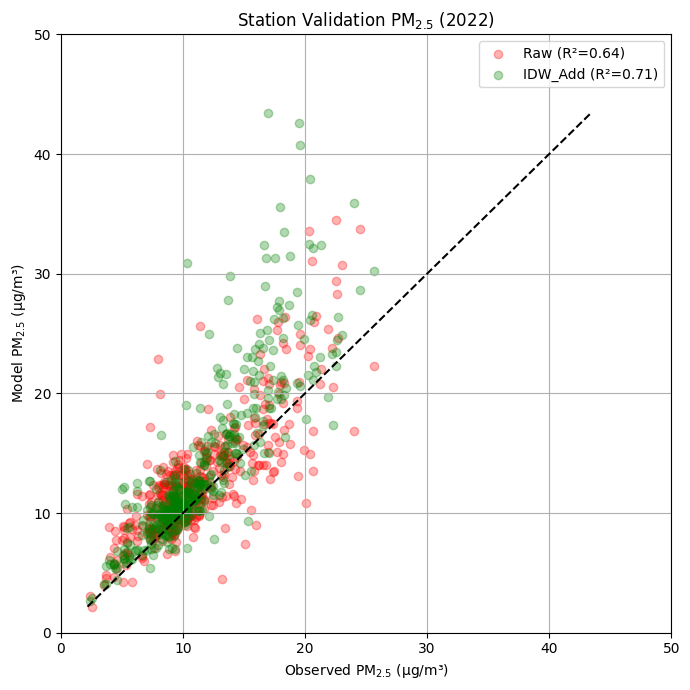

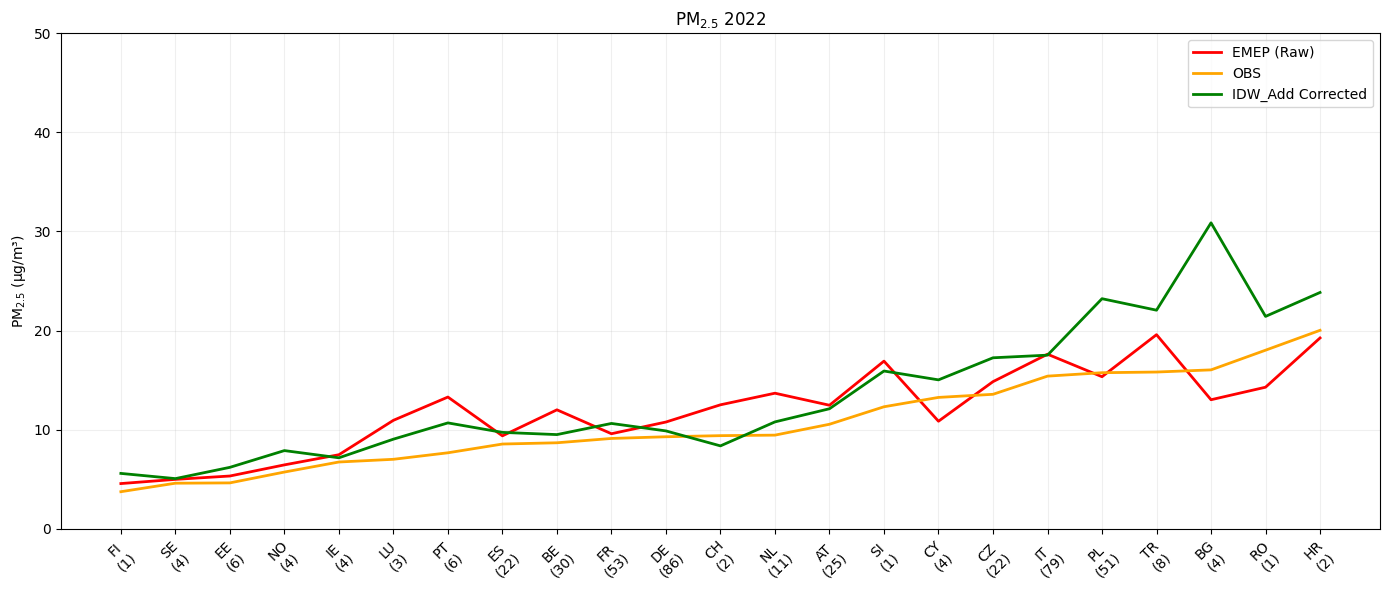

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2022.nc")
ds_wdi = xr.open_dataset("Scen_2022_NKUA_PM25_CSA.Cell.Add.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2022.csv")

# fix longitude if needed
if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. NEAREST GRID CELL (SAME LOGIC)
# ======================================================
def nearest_cell_value(lon_pt, lat_pt, lon, lat, field):
    i = np.argmin(np.abs(lon - lon_pt))
    j = np.argmin(np.abs(lat - lat_pt))
    return field[j, i]

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(nearest_cell_value(lo, la, lon, lat, raw))
    wdi_vals.append(nearest_cell_value(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nWDI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Add (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')
plt.ylim(0,50)
plt.xlim(0,50)
plt.xlabel("Observed PM$_{2.5}$ (μg/m³)")
plt.ylabel("Model PM$_{2.5}$ (μg/m³)")
plt.title("Station Validation PM$_{2.5}$ (2022)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Add Corrected")
plt.ylim(0,50)
plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (μg/m³)")
plt.title("PM$_{2.5}$ 2022")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 3.1507913212379917
MAE: 2.228555734305393
Bias: 0.9427705666379772
R: 0.7689285870488235
R² (corr): 0.5912511719809002
R² (true): 0.3994029963061513

WDI
RMSE: 3.8543331753713583
MAE: 2.313898527043127
Bias: 1.756639580013035
R: 0.8306639787921888
R² (corr): 0.6900026456628698
R² (true): 0.10124279210589815

===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
12      IE  0.581775   0.256511  0.395810   0.123697  0.724575  0.950954   4
3       CH  2.921244   0.645787  2.853963  -0.619828  1.000000  1.000000   2
6       DE  1.917453   0.856367  1.155877   0.385105  0.228551  0.735620  86
20      SE  0.574554   0.906012  0.524249   0.601898  0.995848  0.878999   4
9       FI  0.511760   1.498092  0.511760   1.498092       NaN       NaN   1
15      NL  3.885681   1.538908  3.812862   1.241046  0.031511  0.020945  11
0       AT  2.779093   1.595334  1.151537   0.8798

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


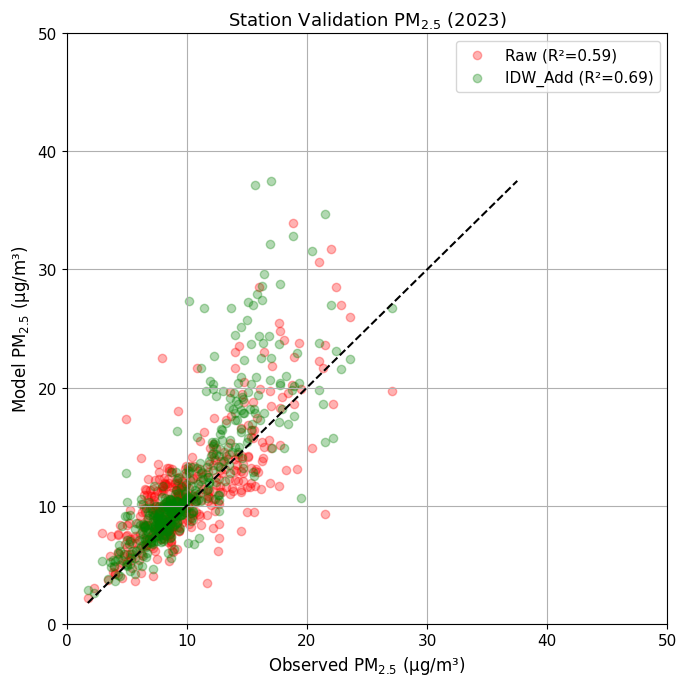

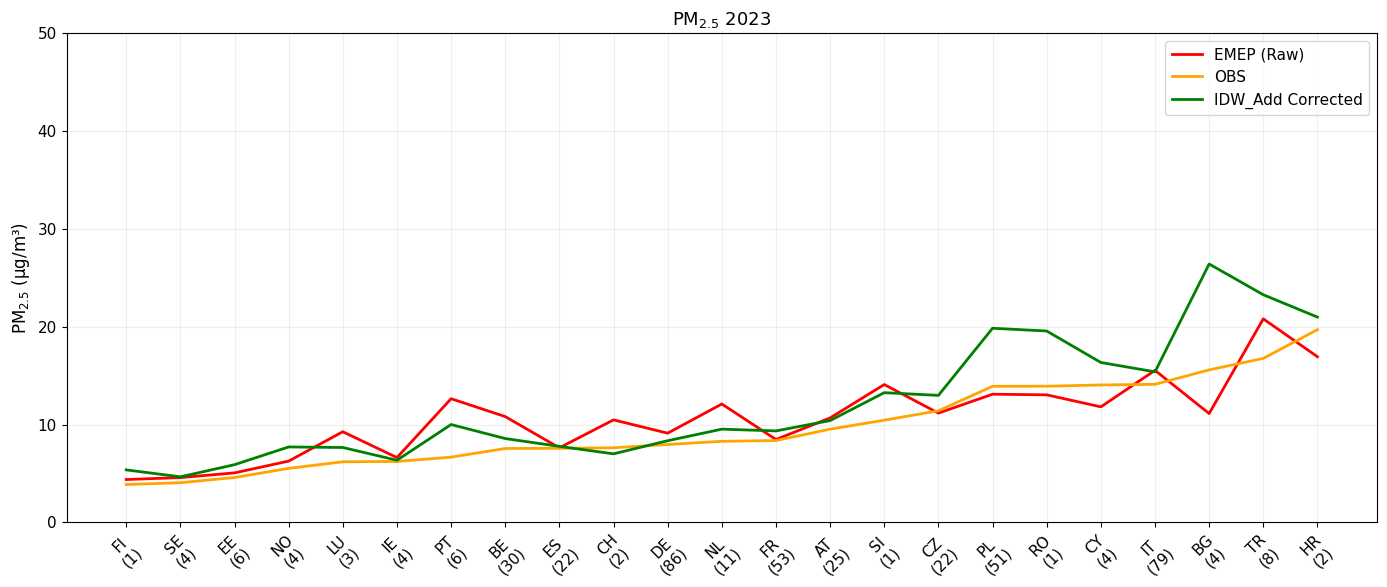

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2023.nc")
ds_wdi = xr.open_dataset("Scen_2023_NKUA_PM25_CSA.Cell.Add.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2023.csv")

# fix longitude if needed
if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. NEAREST GRID CELL (SAME LOGIC)
# ======================================================
def nearest_cell_value(lon_pt, lat_pt, lon, lat, field):
    i = np.argmin(np.abs(lon - lon_pt))
    j = np.argmin(np.abs(lat - lat_pt))
    return field[j, i]

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(nearest_cell_value(lo, la, lon, lat, raw))
    wdi_vals.append(nearest_cell_value(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nWDI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Add (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')
plt.ylim(0,50)
plt.xlim(0,50)
plt.xlabel("Observed PM$_{2.5}$ (μg/m³)")
plt.ylabel("Model PM$_{2.5}$ (μg/m³)")
plt.title("Station Validation PM$_{2.5}$ (2023)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Add Corrected")
plt.ylim(0,50)
plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (μg/m³)")
plt.title("PM$_{2.5}$ 2023")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 4.074107440642437
MAE: 3.0208940998646483
Bias: 2.1651508817116976
R: 0.7574826114865355
R² (corr): 0.5737799067044617
R² (true): 0.02446799414884815

WDI
RMSE: 4.853819328917965
MAE: 3.264223846706755
Bias: 3.0283897176578045
R: 0.8523670247353301
R² (corr): 0.7265295448561588
R² (true): -0.38466202120730775

===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
3       CH  4.371419   0.381081  4.300631   0.356352  1.000000  1.000000   2
12      IE  1.169499   0.796146  0.802684   0.512483  0.434658  0.792690   4
20      SE  0.845550   1.010140  0.716476   0.801361  0.989684  0.941344   4
9       FI  0.507169   1.551020  0.507169   1.551020       NaN       NaN   1
14      LU  2.957456   1.744965  2.828399   1.291615  0.899646  0.042300   3
6       DE  3.101236   1.838075  2.505422   1.620078  0.187522  0.742048  86
15      NL  4.463885   1.858344  4.365032   1.60

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


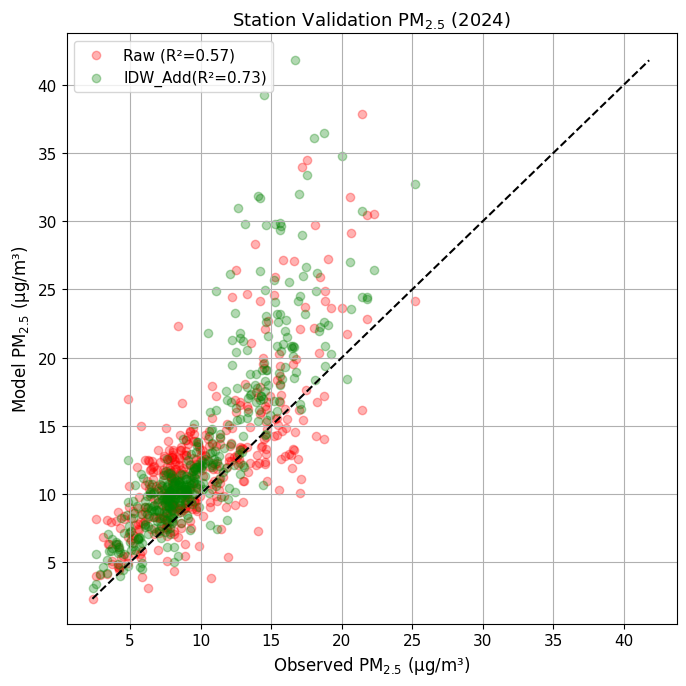

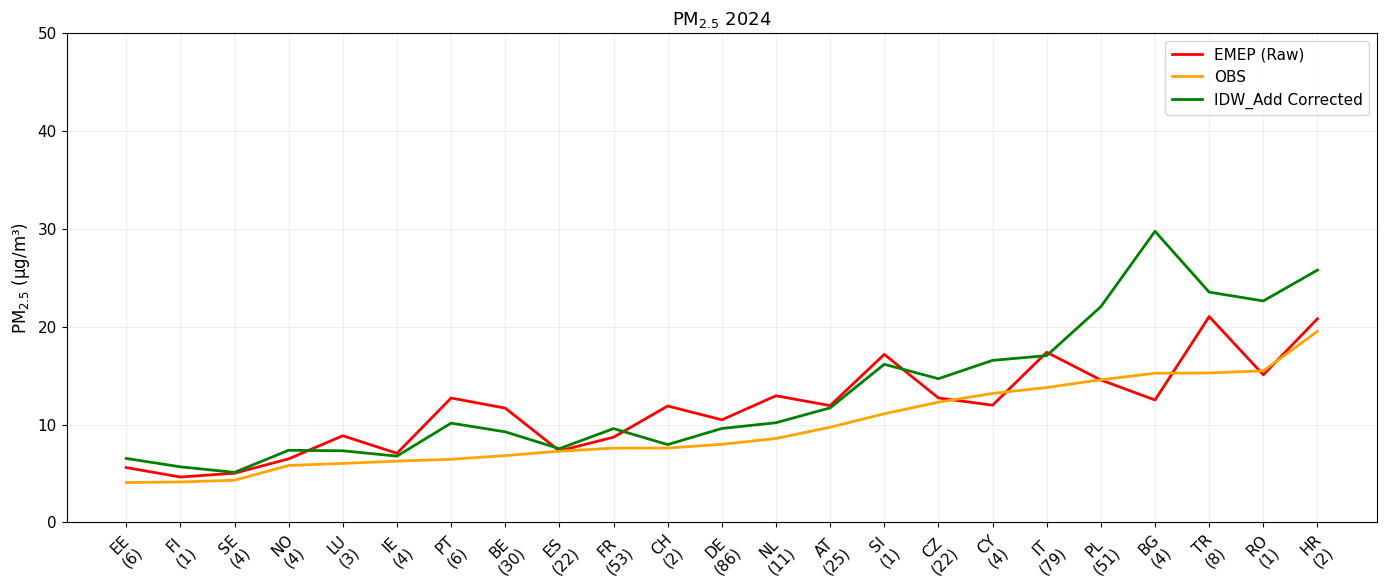

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2024.nc")
ds_wdi = xr.open_dataset("Scen_2024_NKUA_PM25_CSA.Cell.Add.IDW_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2024.csv")

# fix longitude if needed
if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. NEAREST GRID CELL (SAME LOGIC)
# ======================================================
def nearest_cell_value(lon_pt, lat_pt, lon, lat, field):
    i = np.argmin(np.abs(lon - lon_pt))
    j = np.argmin(np.abs(lat - lat_pt))
    return field[j, i]

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(nearest_cell_value(lo, la, lon, lat, raw))
    wdi_vals.append(nearest_cell_value(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nWDI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"IDW_Add(R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')
plt.xlim(0.50)
plt.ylim(0.50)
plt.xlabel("Observed PM$_{2.5}$ (μg/m³)")
plt.ylabel("Model PM$_{2.5}$ (μg/m³)")
plt.title("Station Validation PM$_{2.5}$ (2024)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="IDW_Add Corrected")
plt.ylim(0,50)
plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (μg/m³)")
plt.title("PM$_{2.5}$ 2024")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()